In [1]:
import sys, os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import random

np.random.seed(1337)
random.seed(1337)

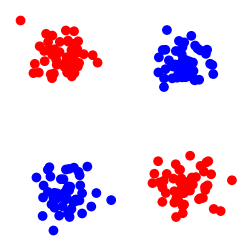

In [83]:
# generate a toy dataset: XOR
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=200, 
    centers=[[-4,-4], [4,4], [4, -4], [-4, 4]],
    center_box=(-15, 15)
)

# limit to two classes for our purposes
y = np.where((y == 0) | (y == 1), -1, 1)

plt.figure(figsize=(3,3))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.axis('off');

In [104]:
# create batched data
from vectorgrad.engine import Tensor
from vectorgrad.nn import MLP, ReLU

model = MLP(2, [16, 16, 1])

# get loss function from micrograd
def loss(batch_size=None):
    
    # inline dataloader
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
        
    yb = Tensor(yb.reshape(-1, 1))
    inputs = Tensor(Xb)
    scores = model(inputs)
    
    # hinge loss
    losses = (1 - yb * scores).relu()
    data_loss = losses.mean()
    
    # L2 regularization
    alpha = 1e-4
    reg_loss = Tensor(0.0)
    for p in model.parameters():
        reg_loss = reg_loss + (p * p).sum()
    reg_loss = alpha * reg_loss
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    preds = scores.data > 0
    targets = yb.data > 0
    accuracy = (preds == targets).mean()
    return total_loss, accuracy

In [108]:
# optimization step / learning step
learning_rate = 0.2
for epoch in range(101):

    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    
    # update (sgd)
    for p in model.parameters():
        p.data -= learning_rate * p.grad
        
    if epoch % 10 == 0:
        print(f"step: {epoch} loss {total_loss.data}, accuracy {acc*100}%")

step: 0 loss 0.9998692806145847, accuracy 93.0%
step: 10 loss 0.9997962199345755, accuracy 97.5%
step: 20 loss 0.9996780836403883, accuracy 98.0%
step: 30 loss 0.9994658698088718, accuracy 100.0%
step: 40 loss 0.999040230115045, accuracy 100.0%
step: 50 loss 0.998045374215204, accuracy 100.0%
step: 60 loss 0.995157438072891, accuracy 100.0%
step: 70 loss 0.9832443759211892, accuracy 100.0%
step: 80 loss 0.8857279202672939, accuracy 100.0%
step: 90 loss 0.009540078850628787, accuracy 100.0%
step: 100 loss 0.003098320840504876, accuracy 100.0%


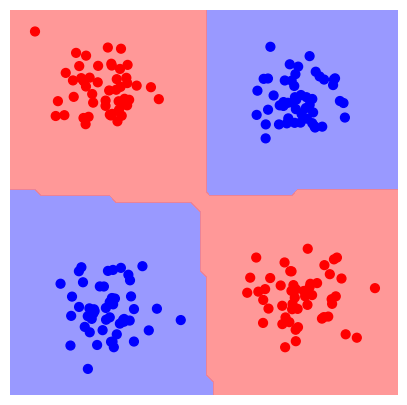

In [116]:
# visualize
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = Tensor(Xmesh)
scores = model(inputs)
Z = np.array(scores.data > 0)
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='bwr')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.axis('off');